# Objetivo analisar a transição dos indicadores sinteses 2010 para 2020 

In [1]:
import pandas as pd

# ajuste o caminho se necessário - workbook com indicadores 2010 e 2022 esperados
df = pd.read_excel('../data/indicadores_2022.xlsx', sheet_name=1)
df.head()

,CD_MUN,NM_MUN,2010_Síntese_D_ECON,2010_Síntese_D_Social,2010_Síntese_D_Ambiental,2022_Síntese_D_ECON,2022_Síntese_D_Social,2022_Síntese_D_Ambiental
0,3300100,Angra dos Reis,Intermediário,Superior,Intermediário,Intermediário,Superior,Superior
1,3300159,Aperibé,Intermediário,Superior,Superior,Superior,Superior,Superior
2,3300209,Araruama,Inferior,Inferior,Inferior,Inferior,Intermediário,Inferior
3,3300225,Areal,Superior,Intermediário,Intermediário,Superior,Intermediário,Intermediário
4,3300233,Armação dos Búzios,Intermediário,Superior,Superior,Intermediário,Intermediário,Intermediário


In [2]:
# ======================
# 2️⃣ Definição de categorias ordenadas
# ======================
categorias = ["Inferior", "Intermediário", "Superior"]
cat_type = pd.CategoricalDtype(categories=categorias, ordered=True)

for col in df.columns:
    if "2010_Síntese" in col or "2022_Síntese" in col:
        df[col] = df[col].astype(cat_type)

In [3]:
# Funções e análise de transição entre 2010 e 2022
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# detectar indicadores que existem para 2010 e 2022 no dataframe
cols = df.columns.astype(str).tolist()

def transition(df, sufixo, normalize=False):
    col_2010 = f'2010_Síntese_{sufixo}'
    col_2022 = f'2022_Síntese_{sufixo}'
    
    print(f"\n=== {sufixo} ===")
    
    # Matriz de transição
    if not normalize:
        return pd.crosstab(df[col_2010], df[col_2022])
    return pd.crosstab(df[col_2010], df[col_2022], normalize="index").round(2)


print(transition(df, 'D_ECON'))

transition(df, 'D_ECON', normalize=True)  



=== D_ECON ===
2022_Síntese_D_ECON  Inferior  Intermediário  Superior
2010_Síntese_D_ECON                                   
Inferior                   16              5         1
Intermediário               8             30         8
Superior                    2              4        18

=== D_ECON ===


2022_Síntese_D_ECON,Inferior,Intermediário,Superior
2010_Síntese_D_ECON,,,
Inferior,0.73,0.23,0.05
Intermediário,0.17,0.65,0.17
Superior,0.08,0.17,0.75



=== D_ECON ===


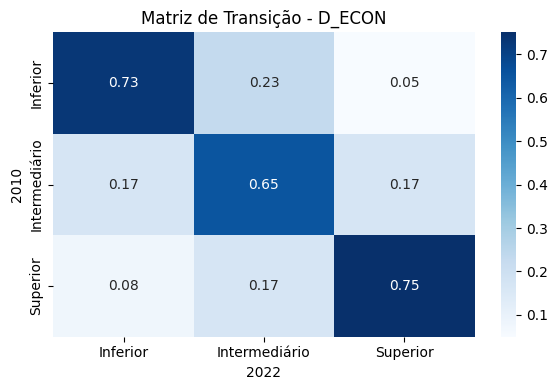

In [4]:
# ======================
# 4️⃣ Visualização Heatmap 
# ======================

def plot_transition_heatmap(mat, sufixo, figsize=(6,4), cmap='Blues', annot=True, fmt='.2f'):
    """Plota um heatmap da matriz de transição para o indicador informado.

    df: DataFrame
    sufixo: sufixo do indicador (ex: 'D_ECON')
    """
    plt.figure(figsize=figsize)
    sns.heatmap(mat, annot=annot, cmap=cmap, fmt=fmt)
    plt.title(f'Matriz de Transição - {sufixo}')
    plt.xlabel('2022')
    plt.ylabel('2010')
    plt.tight_layout()
    plt.show()

matriz = transition(df, 'D_ECON', normalize=True) 
plot_transition_heatmap(matriz, 'D_ECON')

In [164]:
import plotly.graph_objects as go
import plotly.colors as pc

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc
import pandas as pd

def plot_sankey_with_compact_legend(matriz, categorias, prefixo):
    """
    Gera um Sankey estilizado mostrando transições entre categorias 2010 → 2022,
    com cores por direção (melhoria, mantém, piora) e legenda compacta próxima do gráfico.
    """

    # ----------------------
    # Paleta e labels
    # ----------------------
    cores_2010 = pc.qualitative.Pastel[:len(categorias)]
    cores_2022 = pc.qualitative.Set3[:len(categorias)]
    labels = [f"2010 {c}" for c in categorias] + [f"2022 {c}" for c in categorias]

    source, target, value, link_color = [], [], [], []
    cont_melhora, cont_mantem, cont_piora = 0, 0, 0

    for i, c2010 in enumerate(categorias):
        for j, c2022 in enumerate(categorias):
            val = matriz.loc[c2010, c2022] if (c2010 in matriz.index and c2022 in matriz.columns) else 0
            if val > 0:
                source.append(i)
                target.append(len(categorias) + j)
                value.append(val)

                if j > i:
                    cor = "rgba(0, 180, 0, 0.6)"
                    cont_melhora += val
                elif j < i:
                    cor = "rgba(200, 0, 0, 0.6)"
                    cont_piora += val
                else:
                    cor = "rgba(0, 100, 255, 0.5)"
                    cont_mantem += val
                link_color.append(cor)

    # ----------------------
    # Subplots: Sankey + legenda compacta
    # ----------------------
    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[0.8, 0.15],
        specs=[[{"type": "sankey"}, {"type": "scatter"}]],
        horizontal_spacing=0.02
    )

    # Sankey
    fig.add_trace(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="gray", width=0.6),
            label=labels,
            color=cores_2010 + cores_2022,
            hovertemplate='%{label}<extra></extra>'
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_color,
            hovertemplate='De %{source.label} → %{target.label}: %{value}<extra></extra>'
        )
    ), row=1, col=1)

    # Legenda compacta
    fig.add_trace(go.Scatter(
        x=[0]*3,
        y=[2,1,0],
        mode='markers+text',
        marker=dict(size=18, color=["rgba(0, 180, 0, 0.6)", "rgba(0, 100, 255, 0.5)", "rgba(200, 0, 0, 0.6)"]),
        text=[f"Melhoria ({cont_melhora})", f"Mantém ({cont_mantem})", f"Piora ({cont_piora})"],
        textposition="middle left",
        showlegend=False
    ), row=1, col=2)

    # ----------------------
    # Layout geral
    # ----------------------

    fig.update_layout(
        title=dict(
           text=f"<b>Fluxo de Transição {prefixo} (2010 → 2022)  <br> Municípios do RJ</b>",
            x=0.5,
            xanchor="center",
            font=dict(size=16, family="Arial")
        ),
        font=dict(size=12),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=50, r=20, t=60, b=20),
    )

    # Oculta eixos da legenda
    fig.update_xaxes(visible=False, row=1, col=2)
    fig.update_yaxes(visible=False, row=1, col=2)

    fig.show()

matriz = transition(df, 'D_ECON') 

plot_sankey_with_compact_legend(matriz, categorias, 'D_ECON')



=== D_ECON ===


Criar transição dataset

In [147]:
import numpy as np

sufixo = 'D_ECON'
import numpy as np
import pandas as pd

def compute_delta_transition(df: pd.DataFrame, sufixo: str) -> pd.DataFrame:
    """
    Calcula delta, status e transição entre 2010 e 2022 para uma dimensão específica.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo as colunas 2010_Síntese_{sufixo} e 2022_Síntese_{sufixo}
    sufixo : str
        Sufixo da dimensão (ex: 'D_ECON', 'D_Social', 'D_Ambiental')

    Retorna:
    --------
    pd.DataFrame
        DataFrame com três novas colunas:
        - delta_{sufixo}
        - status_{sufixo}
        - transition_{sufixo}
    """

    col_2010 = f'2010_Síntese_{sufixo}'
    col_2022 = f'2022_Síntese_{sufixo}'

    # Certificar que são categóricas ordenadas
    categorias = ["Inferior", "Intermediário", "Superior"]
    df[col_2010] = df[col_2010].astype(pd.CategoricalDtype(categories=categorias, ordered=True))
    df[col_2022] = df[col_2022].astype(pd.CategoricalDtype(categories=categorias, ordered=True))

    # Calcular delta
    df[f'delta_{sufixo}'] = df[col_2022].cat.codes - df[col_2010].cat.codes

    # Criar status com base no delta
    conditions = [
        df[f'delta_{sufixo}'] == 2,
        df[f'delta_{sufixo}'] == 1,
        df[f'delta_{sufixo}'] == 0,
        df[f'delta_{sufixo}'] == -1,
        df[f'delta_{sufixo}'] == -2,
    ]
    status = ['Melhora Forte', 'Melhora Leve', 'Mantém', 'Piora Leve', 'Piora Forte']
    df[f'status_{sufixo}'] = np.select(conditions, status, default='Desconhecido')

    # Criar coluna de transição
    df[f'transition_{sufixo}'] = df[col_2010].astype(str) + " → " + df[col_2022].astype(str)

    return df
df = compute_delta_transition(df, sufixo)

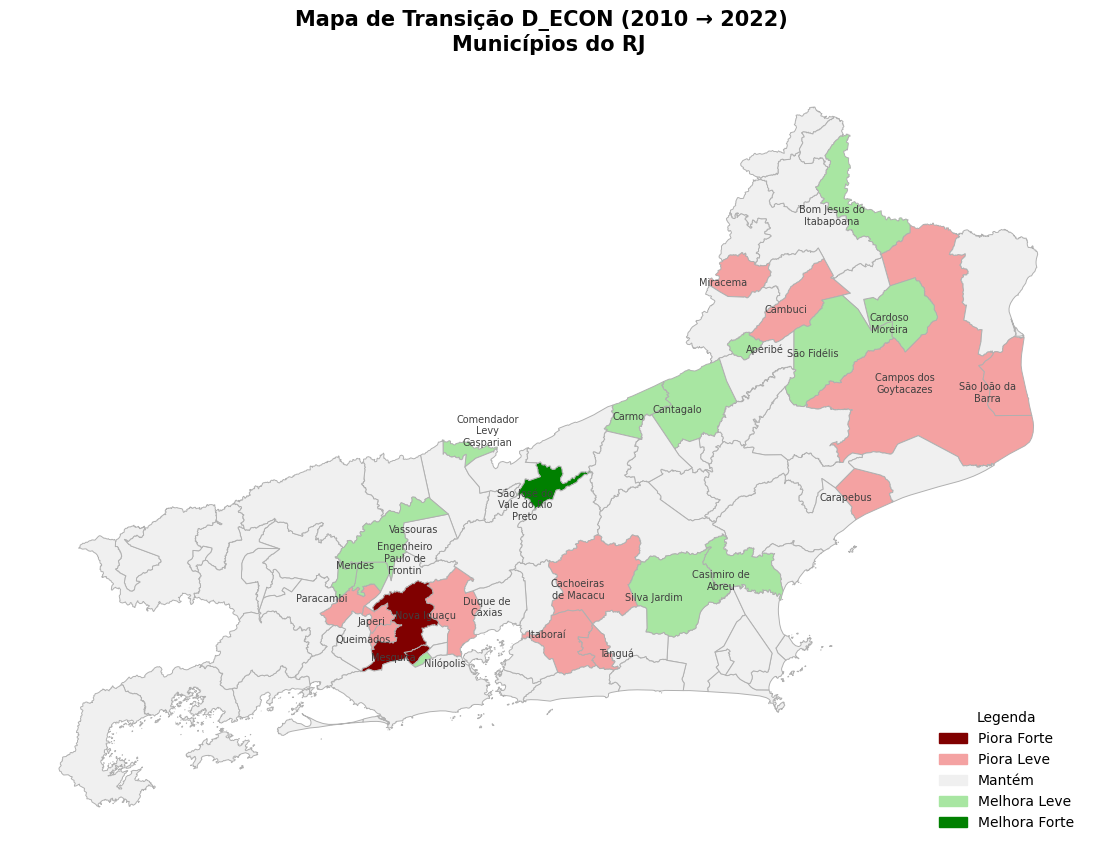

In [151]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.patches as mpatches
import textwrap
from geobr import read_municipality

def plot_municipio_delta_map(df: pd.DataFrame, sufixo: str, width_text=12):
    """
    Plota mapa dos municípios do RJ com cores baseadas no delta/status.
    
    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo colunas 'CD_MUN' e f'status_{sufixo}'
    sufixo : str
        Sufixo da dimensão (ex: 'D_ECON', 'D_Social', 'D_Ambiental')
    width_text : int
        Largura máxima de caracteres por linha nos nomes dos municípios
    
    Retorna:
    --------
    Matplotlib figure com o mapa.
    """
    
    # -----------------------------
    # 1️⃣ Carregar GeoDataFrame dos municípios do RJ
    # -----------------------------
    gdf = read_municipality(code_muni="RJ", year=2022, simplified=True)
    gdf['CD_MUN'] = gdf['code_muni'].astype('Int64')
    gdf = gdf.merge(df, on='CD_MUN', how='left')

    # -----------------------------
    # 2️⃣ Definir cores
    # -----------------------------
    delta_colors = {
        "Piora Forte": "#800000",
        "Piora Leve": "#f4a2a2",
        "Mantém": "#f0f0f0",
        "Melhora Leve": "#a8e6a2",
        "Melhora Forte": "#008000"
    }

    fill_colors = [delta_colors.get(x, "#f0f0f0") for x in gdf[f'status_{sufixo}']]

    # -----------------------------
    # 3️⃣ Criar mapa
    # -----------------------------
    fig, ax = plt.subplots(1, 1, figsize=(16,10))
    gdf.plot(
        color=fill_colors,
        edgecolor='#b0b0b0',
        linewidth=.7,
        ax=ax
    )

    # Adicionar nomes dos municípios (com wrap)
    texts = []
    for _, row in gdf.iterrows():
        x = row.geometry.centroid.x
        y = row.geometry.centroid.y
        if row[f'status_{sufixo}'] == "Mantém":
            continue
        txt = ax.text(
            x, y, textwrap.fill(row['NM_MUN'], width=width_text),
            fontsize=7, color='#404040',
            ha='center', va='center', zorder=10
        )
        texts.append(txt)

    adjust_text(texts, ax=ax)

    # -----------------------------
    # 4️⃣ Legenda manual
    # -----------------------------
    legend_patches = [mpatches.Patch(color=color, label=label) for label, color in delta_colors.items()]
    ax.legend(handles=legend_patches, title='Legenda', loc='lower right', frameon=False)

    # -----------------------------
    # 5️⃣ Ajustes finais
    # -----------------------------
    ax.set_axis_off()
    ax.set_title(f'Mapa de Transição {sufixo} (2010 → 2022)  \nMunicípios do RJ',
                 fontsize=15, weight='bold', pad=15)
    
    plt.show()

plot_municipio_delta_map(df, 'D_ECON')